# Analítica de Dados Empresariais
# Mestrado em Ciência de Dados para Empresas
## Machine Learning – Previsão de Churn de Clientes
Fluxo do trabalho:

Dados → Exploração → Preparação → Modelo → Avaliação → Risco → Ação de negócio


## 1. Importação das bibliotecas

In [1]:
# Ignorar avisos menos relevantes
import warnings
warnings.filterwarnings("ignore")

# Bibliotecas principais de análise
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Avaliação
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

# Mostrar pipelines em diagrama
from sklearn import set_config
set_config(display="diagram")


## 2. Carregar o dataset

In [2]:
df = pd.read_csv("ADE_Sessao_ML_Dataset_Churn.csv")

print("Dataset carregado com sucesso")
print("Dimensão:", df.shape)

print("\nPrimeiras linhas:")
print(df.head().to_string(index=False))


Dataset carregado com sucesso
Dimensão: (1200, 12)

Primeiras linhas:
CustomerID  StartDate  TenureMonths ContractType  Channel   Region  MonthlyFee  AvgWeeklyUsage  SupportTickets_90d  LatePayments_12m  NPS  Churn_3m
   C100000 2021-07-14             6       Mensal   Online Alentejo       41.98            3.14                   0                 0   21         1
   C100001 2021-06-10            46       Mensal Parceiro  Algarve       29.98            1.01                   1                 0   43         0
   C100002 2021-12-18            39       Mensal     Loja   Centro       34.91            5.14                   1                 0  -15         0
   C100003 2023-05-23            26       Mensal   Online  Algarve       12.72            4.09                   0                 0   40         1
   C100004 2022-03-07            26        Anual   Online Alentejo       22.75            2.95                   1                 0   28         0


## 3. Compreender os dados

In [3]:
print("Número de clientes:", len(df))

# garantir que a coluna é numérica
df["Churn_3m"] = pd.to_numeric(df["Churn_3m"], errors="coerce")

taxa_churn = df["Churn_3m"].mean()

print("Taxa de churn:", round(taxa_churn,3))
print("Taxa de churn (%):", round(taxa_churn*100,1), "%")

print("\nInformação estrutural:")
df.info()

print("\nTipos de dados:")
print(df.dtypes)

Número de clientes: 1200
Taxa de churn: 0.228
Taxa de churn (%): 22.8 %

Informação estrutural:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          1200 non-null   object 
 1   StartDate           1200 non-null   object 
 2   TenureMonths        1200 non-null   int64  
 3   ContractType        1200 non-null   object 
 4   Channel             1200 non-null   object 
 5   Region              1200 non-null   object 
 6   MonthlyFee          1200 non-null   float64
 7   AvgWeeklyUsage      1200 non-null   float64
 8   SupportTickets_90d  1200 non-null   int64  
 9   LatePayments_12m    1200 non-null   int64  
 10  NPS                 1200 non-null   int64  
 11  Churn_3m            1200 non-null   int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 112.6+ KB

Tipos de dados:
CustomerID             object


## 4. Exploração visual

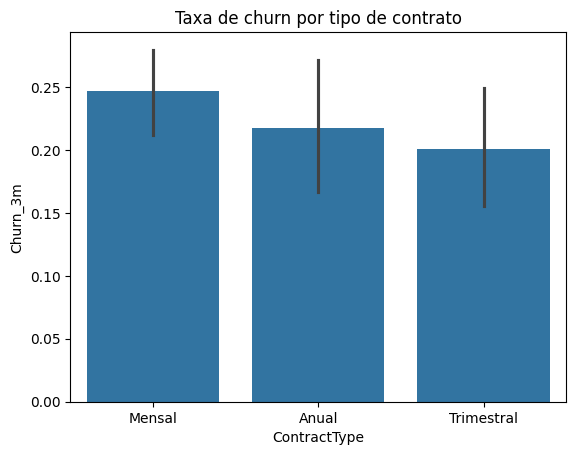

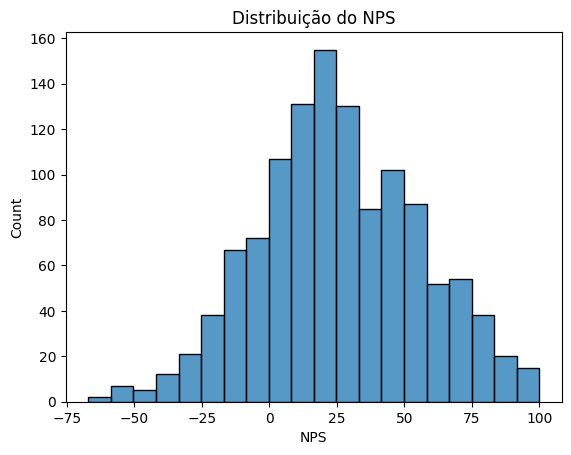

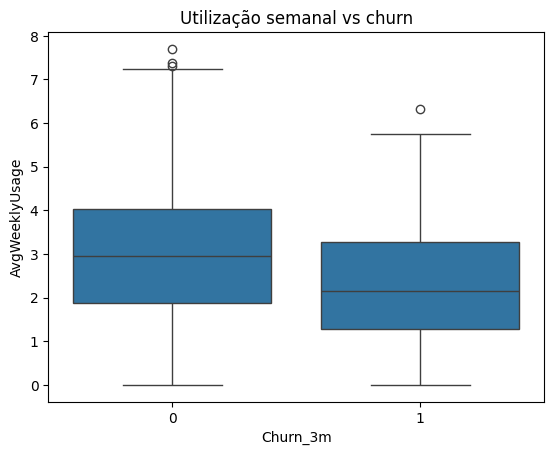

In [4]:
sns.barplot(data=df,x="ContractType",y="Churn_3m")
plt.title("Taxa de churn por tipo de contrato")
plt.show()

sns.histplot(df["NPS"],bins=20)
plt.title("Distribuição do NPS")
plt.show()

sns.boxplot(data=df,x="Churn_3m",y="AvgWeeklyUsage")
plt.title("Utilização semanal vs churn")
plt.show()


## 5. Definição das variáveis

In [5]:
target="Churn_3m"

features=[
"TenureMonths",
"ContractType",
"Channel",
"Region",
"MonthlyFee",
"AvgWeeklyUsage",
"SupportTickets_90d",
"LatePayments_12m",
"NPS"
]

X=df[features]
y=df[target]

print("Variável alvo:",target)
print("\nVariáveis explicativas:")

for f in features:
    print("-",f)


Variável alvo: Churn_3m

Variáveis explicativas:
- TenureMonths
- ContractType
- Channel
- Region
- MonthlyFee
- AvgWeeklyUsage
- SupportTickets_90d
- LatePayments_12m
- NPS


## 6. Tipos de variáveis

In [6]:
num=[
"TenureMonths",
"MonthlyFee",
"AvgWeeklyUsage",
"SupportTickets_90d",
"LatePayments_12m",
"NPS"
]

cat=[
"ContractType",
"Channel",
"Region"
]

print("Numéricas:",num)
print("Categóricas:",cat)


Numéricas: ['TenureMonths', 'MonthlyFee', 'AvgWeeklyUsage', 'SupportTickets_90d', 'LatePayments_12m', 'NPS']
Categóricas: ['ContractType', 'Channel', 'Region']


## 7. Divisão treino/teste

In [7]:
X_train,X_test,y_train,y_test=train_test_split(
X,y,
test_size=0.25,
random_state=42,
stratify=y
)

print("Treino:",X_train.shape)
print("Teste:",X_test.shape)


Treino: (900, 9)
Teste: (300, 9)


## 8. Pipeline de preparação dos dados

In [8]:
num_pipe=Pipeline([ 
    ("imputer",SimpleImputer(strategy="median")), 
    ("scaler",StandardScaler()) 
    ]) 
cat_pipe=Pipeline([ 
    ("imputer",SimpleImputer(strategy="most_frequent")), 
    ("encoder",OneHotEncoder(handle_unknown="ignore")) 
    ]) 
prep=ColumnTransformer([ 
    ("num",num_pipe,num), 
    ("cat",cat_pipe,cat) 
    ]) 
print("Pipeline de preparação criado com sucesso")

display(prep)


Pipeline de preparação criado com sucesso


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 9. Construção do modelo

In [9]:
model=Pipeline([
("prep",prep),
("clf",LogisticRegression(max_iter=1000,class_weight="balanced"))
])

model.fit(X_train,y_train)

print("Modelo treinado com sucesso")

display(model)


Modelo treinado com sucesso


,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 10. Avaliação do modelo

              precision    recall  f1-score   support

           0       0.82      0.63      0.72       232
           1       0.30      0.53      0.38        68

    accuracy                           0.61       300
   macro avg       0.56      0.58      0.55       300
weighted avg       0.70      0.61      0.64       300

ROC AUC: 0.6189781947261663


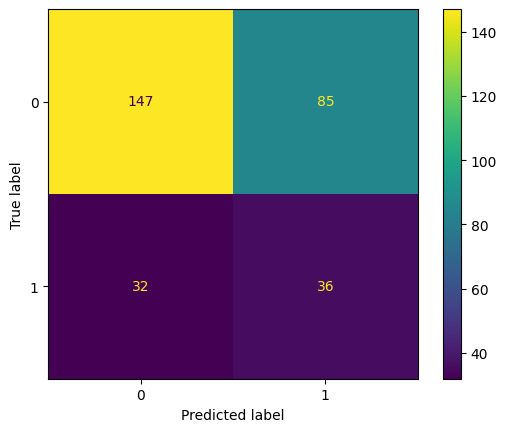

In [10]:
pred=model.predict(X_test)
proba=model.predict_proba(X_test)[:,1]

print(classification_report(y_test,pred))

print("ROC AUC:",roc_auc_score(y_test,proba))

ConfusionMatrixDisplay.from_predictions(y_test,pred)
plt.show()



## 11. Cálculo do risco de churn

In [11]:
df_scored=df.copy()

df_scored["ChurnRisk"]=model.predict_proba(X)[:,1]

print("Maior risco:",df_scored["ChurnRisk"].max())

print(df_scored[["CustomerID","ChurnRisk"]].head().to_string(index=False))


Maior risco: 0.8875890666499339
CustomerID  ChurnRisk
   C100000   0.411258
   C100001   0.744838
   C100002   0.365022
   C100003   0.414167
   C100004   0.423283


## 12. Estratégia de retenção

In [12]:
def action(r):

    if r>=0.50:
        return "Contacto imediato + oferta personalizada"

    if r>=0.40:
        return "Campanha de retenção"

    if r>=0.30:
        return "Monitorizar cliente"

    return "Comunicação regular"

df_scored["Recomendacao"]=df_scored["ChurnRisk"].apply(action)

print(df_scored["Recomendacao"].value_counts())


Recomendacao
Contacto imediato + oferta personalizada    504
Campanha de retenção                        304
Monitorizar cliente                         232
Comunicação regular                         160
Name: count, dtype: int64


## 13. Distribuição das estratégias

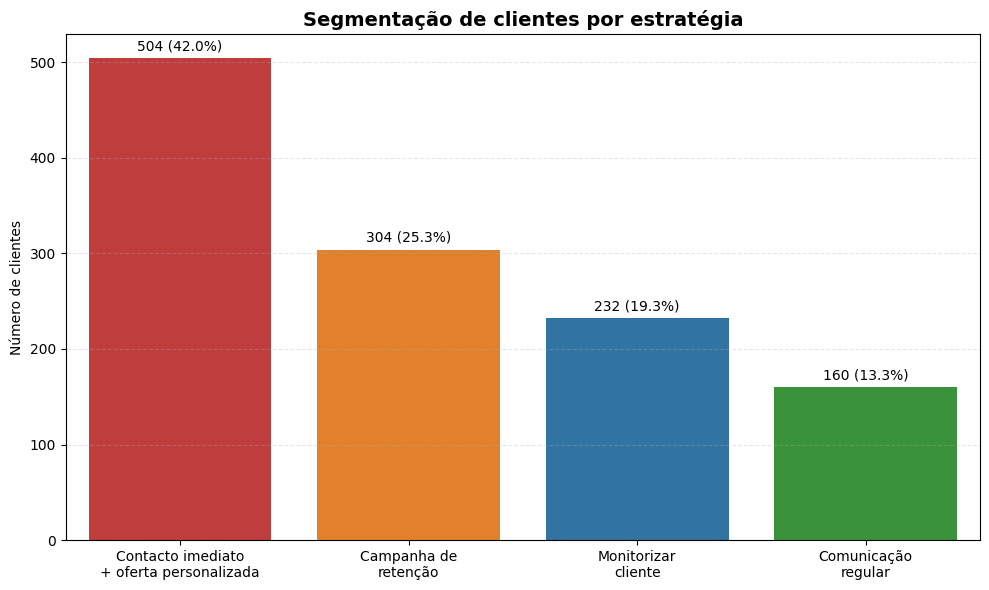

In [13]:
# Contagem e ordenação por nível de risco
ordem = [
    "Contacto imediato\n+ oferta personalizada",
    "Campanha de\nretenção",
    "Monitorizar\ncliente",
    "Comunicação\nregular"
]

# Criar cópia apenas para melhorar os rótulos do gráfico
df_plot = df_scored.copy()

df_plot["Recomendacao_plot"] = df_plot["Recomendacao"].replace({
    "Contacto imediato + oferta personalizada": "Contacto imediato\n+ oferta personalizada",
    "Campanha de retenção": "Campanha de\nretenção",
    "Monitorizar cliente": "Monitorizar\ncliente",
    "Comunicação regular": "Comunicação\nregular"
})

counts = df_plot["Recomendacao_plot"].value_counts().reindex(ordem)

# Percentagens
percent = counts / counts.sum() * 100

# Cores por criticidade
cores = ["#d62728", "#ff7f0e", "#1f77b4", "#2ca02c"]

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=counts.index,
    y=counts.values,
    palette=cores
)

plt.title("Segmentação de clientes por estratégia", fontsize=14, weight="bold")
plt.xlabel("")
plt.ylabel("Número de clientes")

# Valores e percentagens
for i, (val, pct) in enumerate(zip(counts.values, percent)):
    ax.text(i, val + 8, f"{val} ({pct:.1f}%)", ha="center", fontsize=10)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


## 14. Clientes prioritários

In [14]:
clientes_prioritarios=df_scored.sort_values(
"ChurnRisk",
ascending=False
)[[
"CustomerID",
"ContractType",
"NPS",
"AvgWeeklyUsage",
"SupportTickets_90d",
"LatePayments_12m",
"ChurnRisk",
"Recomendacao"
]].head(20)

print("CLIENTES PRIORITÁRIOS")
print(clientes_prioritarios.to_string(index=False))


CLIENTES PRIORITÁRIOS
CustomerID ContractType  NPS  AvgWeeklyUsage  SupportTickets_90d  LatePayments_12m  ChurnRisk                             Recomendacao
   C100145       Mensal  -55            0.00                   0                 0   0.887589 Contacto imediato + oferta personalizada
   C100631       Mensal   -8            0.00                   1                 1   0.856263 Contacto imediato + oferta personalizada
   C100455       Mensal  -38            0.74                   0                 0   0.835825 Contacto imediato + oferta personalizada
   C100390       Mensal   -5            0.07                   4                 0   0.827830 Contacto imediato + oferta personalizada
   C100771       Mensal    3            0.02                   1                 0   0.812722 Contacto imediato + oferta personalizada
   C100945       Mensal  -12            0.02                   1                 0   0.802931 Contacto imediato + oferta personalizada
   C100274       Mensal  -13     

## 15. Distribuição do risco

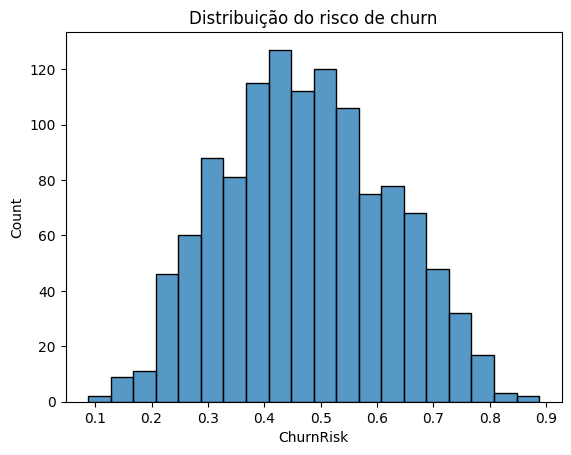

In [15]:
sns.histplot(df_scored["ChurnRisk"],bins=20)
plt.title("Distribuição do risco de churn")
plt.show()
